<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Autoencoders</h1>
<h2>What are autoencoders?</h2>
<p>"Auto" means self. "Encoding" means converting to a different form, typically to something simpler. An autoencoder model is a model that teaches itself how to enode information.</p>
<img src="../../assets/dudl-10-autoencoder.png">
<p>Typically the latent layer is the smallest and the input-output layers are the largest. The goal is to train a model to produce an output as similar to the input as possible.</p>
<p>Autoencoders are used for data compression, dimension-reducing, data cleaning, feature extraction, anomaly detection and retraining deep or complex models.</p>
</div>

In [99]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import kagglehub as khg

In [100]:
path = khg.dataset_download("oddrationale/mnist-in-csv", output_dir='../../assets/mnist')
print(path)

../../assets/mnist


In [101]:
testData = np.loadtxt('../../assets/mnist/mnist_test.csv', delimiter=',', dtype=str)
trainData = np.loadtxt('../../assets/mnist/mnist_train.csv', delimiter=',', dtype=str)

print(trainData.shape)
print(testData.shape)

trainData

(60001, 785)
(10001, 785)


array([['label', '1x1', '1x2', ..., '28x26', '28x27', '28x28'],
       ['5', '0', '0', ..., '0', '0', '0'],
       ['0', '0', '0', ..., '0', '0', '0'],
       ...,
       ['5', '0', '0', ..., '0', '0', '0'],
       ['6', '0', '0', ..., '0', '0', '0'],
       ['8', '0', '0', ..., '0', '0', '0']],
      shape=(60001, 785), dtype='<U5')

In [102]:
data = np.vstack((np.array(trainData[1:, 1:], dtype=np.float64), np.array(testData[1:, 1:], dtype=np.float64)))
data = data / np.max(data)
data = torch.tensor(data).float()
print(data)
print(data.shape)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
torch.Size([70000, 784])


In [103]:
def createTheMnistAe():
    class aenet(nn.Module):
        def __init__(self):
            super().__init__()
            self.input = nn.Linear(784, 250)
            self.encoder = nn.Linear(250, 50)
            self.latent = nn.Linear(50, 250)
            self.decoder = nn.Linear(250, 784)
        
        def forward(self, x):
            x = F.relu(self.input(x))
            x = F.relu(self.encoder(x))
            x = F.relu(self.latent(x))
            y = torch.sigmoid(self.decoder(x))
            return y
    
    net = aenet()
    return net, nn.MSELoss(), torch.optim.Adam(net.parameters(), lr=0.001)

def trainAeModel():
    net, lossfun, optimizer = createTheMnistAe()
    numberOfEpochs = 30_000
    losses = torch.zeros(numberOfEpochs)

    for i in range(numberOfEpochs):
        randomidx = np.random.choice(data.shape[0], size=32)
        x = data[randomidx, :]
        yHat = net(x)
        loss = lossfun(yHat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses[i] = loss.item()
    
    return losses, net

In [104]:
net, lossfunction, optimizer = createTheMnistAe()
x = data[:5, :]
yHat = net(x)

print(x.shape)
print(yHat.shape)

torch.Size([5, 784])
torch.Size([5, 784])


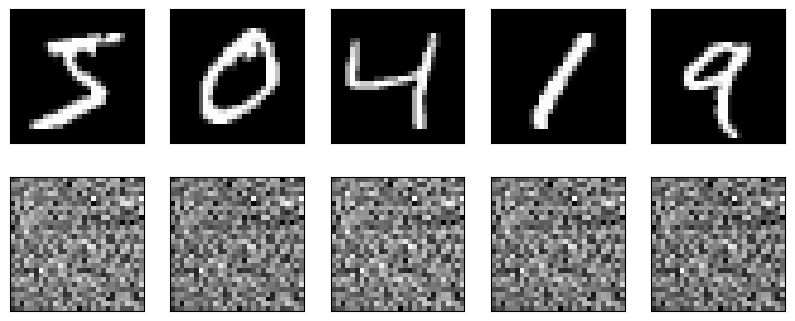

In [105]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axs[0, i].imshow(x[i, :].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(yHat[i, :].view(28, 28).detach(), cmap='gray')
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])

plt.show()

Final loss: 0.0053


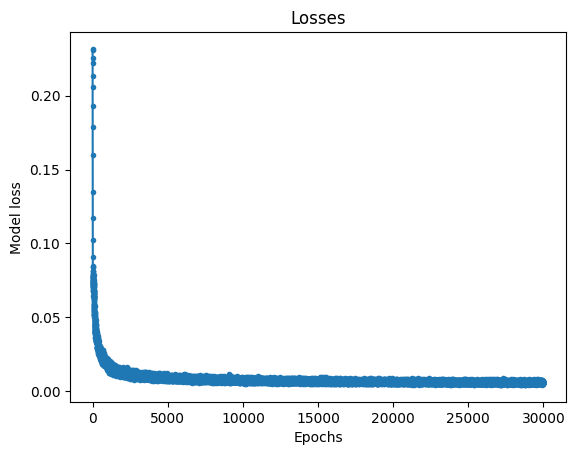

In [106]:
losses, net = trainAeModel()
print(f'Final loss: {losses[-1]:.4f}')

plt.plot(losses, '.-')
plt.xlabel('Epochs')
plt.ylabel('Model loss')
plt.title('Losses')
plt.show()

torch.Size([5, 784])
torch.Size([5, 784])


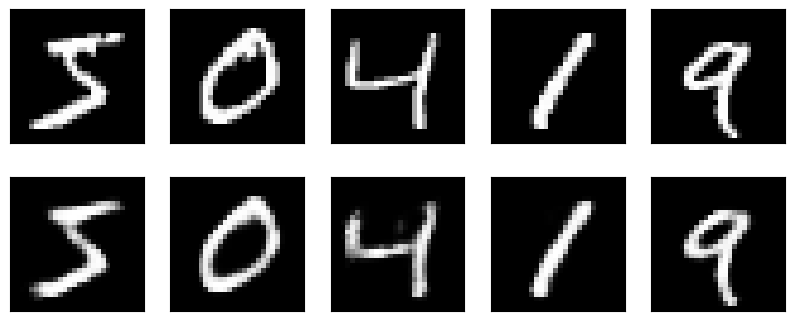

In [107]:
x = data[:5, :]
yHat = net(x)

print(x.shape)
print(yHat.shape)

fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axs[0, i].imshow(x[i, :].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(yHat[i, :].view(28, 28).detach(), cmap='gray')
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])

plt.show()

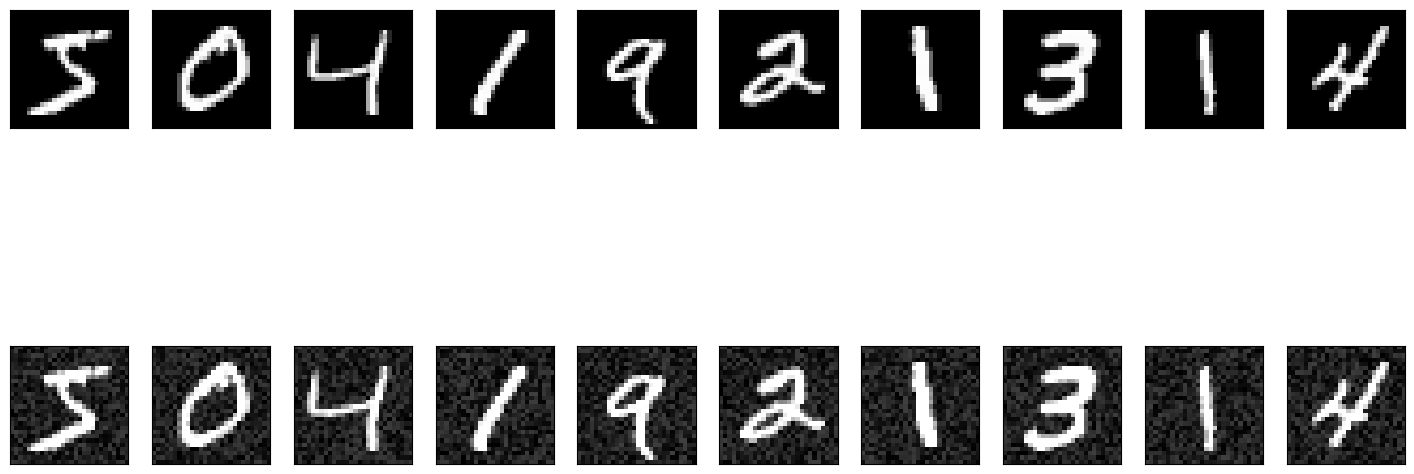

In [108]:
x = data[:10, :]
noisyX = x + torch.rand_like(x) / 4
noisyX[noisyX > 1] = 1

fig, axs = plt.subplots(2, 10, figsize=(18, 8))
for i in range(10):
    axs[0, i].imshow(x[i,:].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(noisyX[i, :].view(28, 28).detach(), cmap='gray')
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])

plt.show()

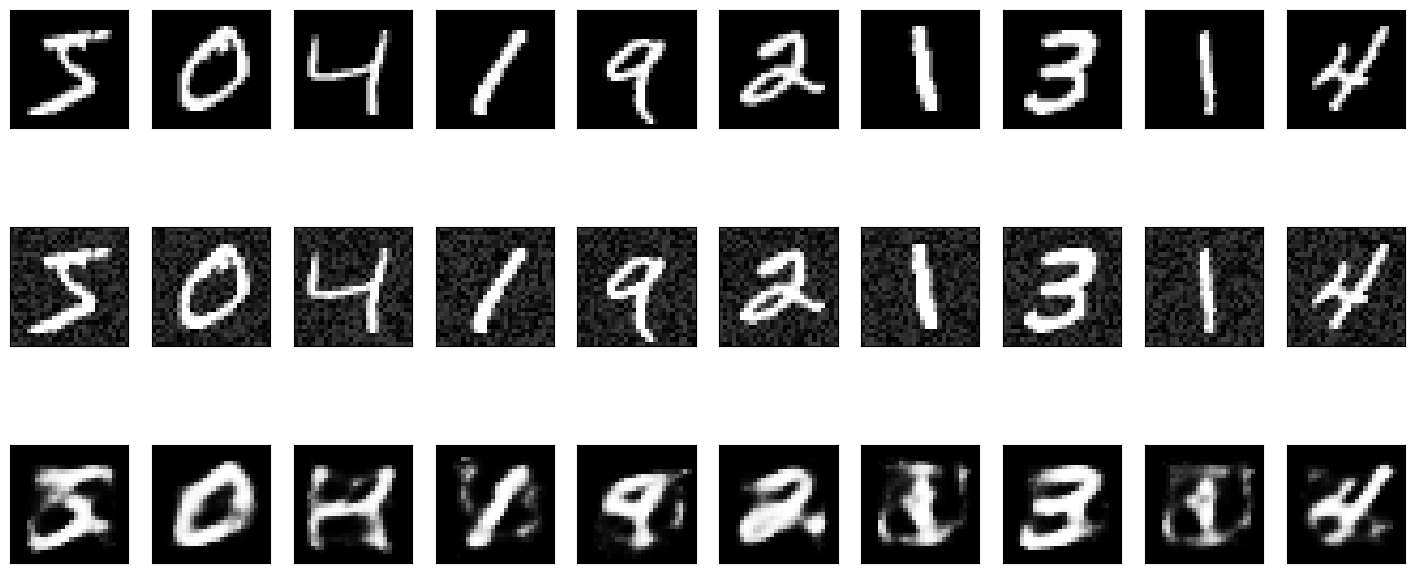

In [109]:
y = net(noisyX)

fig, axs = plt.subplots(3, 10, figsize=(18, 8))
for i in range(10):
    axs[0, i].imshow(x[i,:].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(noisyX[i, :].view(28, 28).detach(), cmap='gray')
    axs[2, i].imshow(y[i, :].view(28, 28).detach(), cmap='gray')

    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])
    axs[2, i].set_xticks([])
    axs[2, i].set_yticks([])
plt.show()